how can we support fast “give me 20 similar songs” queries when feature vectors are high-dimensional?

11/11-2025

Cluster the songs based on the feature vectors:<br> 
Algorithms like **k-means** or **DBSCAN** can be used for the clustering. <br>
Optionally, it is possible to build a **k-nearest-neighbour graph** from similarity scores and run a graph clustering method (e.g. **community detection**) to find “music communities”.

### **Cluster the LSH data:** 

Note: The previous step (**Step 2**), did Locality Sensitive Hashing (LSH) on the feature vectors to generate approximate nearest neighbours.
<br>
LSH maps similar songs into the same or nearby hash buckets with high probability. These buckets allow us to quickly retrieve candidate sets of similar songs without computing all pairwise distances, between every single vector.
<br>
During clustering, this pre-processing step can significantly reduce computation time, since comparisons can be limited to items within the same or similar buckets instead of the entire dataset.
<br>
<br>
Thus, LSH acts as a pre-treatment that enables scalable similarity search and accelerates the downstream clustering, performed in this notebook. 

**Load main data:**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset_with_lastfm_all.csv")

# Keep original index for alignment with LSH signatures
df = df.reset_index(drop=True)

# Select numeric features for K-means
feature_cols = df.select_dtypes(include=[np.number]).columns
X = df[feature_cols].to_numpy()


**Load LSH signatures from last notebook:**

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

# Load LSH signatures
ARTIFACT_DIR = Path("../artifacts")
LSH = np.load(ARTIFACT_DIR / "lsh_signatures.npz")
lsh_bits = LSH["lsh_bits"]           # shape (n_items, 128)
n_tables = int(LSH["n_tables"])      # 8
n_bits_per_table = int(LSH["n_bits_per_table"])  # 16

print("LSH bits shape:", lsh_bits.shape)

# Load real features
df = pd.read_csv("../dataset_with_lastfm_all.csv")
df = df.reset_index(drop=True)
X = df.select_dtypes(include=[np.number]).to_numpy()

n_items = lsh_bits.shape[0]


LSH bits shape: (55129, 128)


In [18]:
# Split lsh_bits into tables
table_sigs = np.split(lsh_bits, n_tables, axis=1)  # 8 tables

In [19]:
from collections import defaultdict

buckets_per_table = [defaultdict(list) for _ in range(n_tables)]

for t, table in enumerate(table_sigs):
    for i, row in enumerate(table):
        bucket_id = tuple(row.tolist())  # hashable 16-bit signature
        buckets_per_table[t][bucket_id].append(i)


In [20]:
#Checking that bucket size looks correct: 
bucket_sizes = [len(members) for table in buckets_per_table for members in table.values()]
print("Total hash buckets:", len(bucket_sizes))
print("Average bucket size:", np.mean(bucket_sizes))


Total hash buckets: 137083
Average bucket size: 3.2172625343769834


**Build candidate neighborhoods:**

In [21]:
candidate_sets = [set() for _ in range(n_items)]

for table in buckets_per_table:
    for bucket_id, members in table.items():
        if len(members) < 5:     # skip very small buckets
            continue
        for idx in members:
            candidate_sets[idx].update(members)


In [22]:
print("Avg candidate size:", np.mean([len(s) for s in candidate_sets]))
print("Max candidate size:", np.max([len(s) for s in candidate_sets]))


Avg candidate size: 69.65910863610804
Max candidate size: 524


**Remove duplicate candidate groups:**

In [23]:
unique_groups = {}  # frozen_set → list of indices

for idx, s in enumerate(candidate_sets):
    key = frozenset(s)
    if key not in unique_groups:
        unique_groups[key] = []
    unique_groups[key].append(idx)

print("Unique candidate groups:", len(unique_groups))


Unique candidate groups: 50254


**Run LSH-accelerated K-means:**

In [24]:
#There are NA values, which need to be replaced using imputers: 
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

X = X_imputed  # replace original X

/home/henrikk17/miniconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: [3]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [ ]:
from sklearn.cluster import KMeans

labels_global = -1 * np.ones(n_items, dtype=int)
cluster_base = 0

K = 5  # number of clusters per group

for cand_set, members in unique_groups.items():
    indices = list(cand_set)

    if len(indices) < 40:   # threshold; tune
        continue

    X_sub = X[indices]

    kmeans = KMeans(n_clusters=K, n_init="auto", random_state=42)
    sub_labels = kmeans.fit_predict(X_sub)

    # assign cluster labels back to the original indices
    for idx, label in zip(indices, sub_labels):
        labels_global[idx] = cluster_base + label

    cluster_base += K




In [ ]:
#Inspecting some of the clustering results: 
print(labels_global.shape)
print(labels_global[:50])


(55129,)
[134272 153616 110562 151992 150296 149181 110236 153026 146347 152225
 150132 150622 146564 116880 152232 144093 148745 153709 148499 149685
 150794 142410 147149 153165 153586 151884 152792 151120 152775 153569
 152135 152425 152360 153065 144785 152149 150809 145927 127315 152775
 153645  20185  65406 105051 151297 153214 151595 153534 145840 149670]


In [30]:
X.shape

(73608, 18)

In [ ]:
labels_global.shape 
#Note: LSH candidate clustering only assigned labels to a subset of rows (55,129 items), 
#while X contains all features including some rows that were never clustered.

(55129,)

**Visualizing clustering results using PCA and T-SNE:**

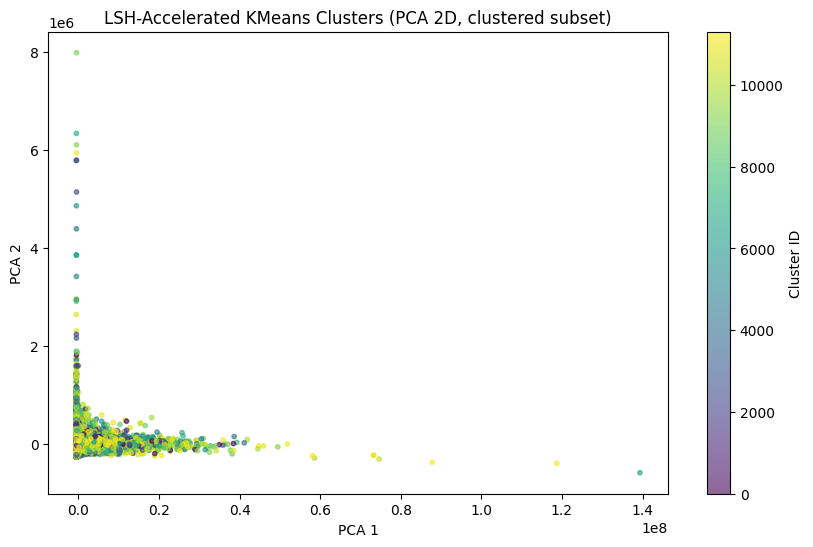

In [34]:
# Identify clustered rows
clustered_mask = labels_global != -1  # labels_global only exists for 55129 items

# Subset X to match labels
X_clustered = X[:labels_global.shape[0], :]  # first 55129 rows must correspond to labels_global
labels = labels_global

# PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustered)

# Map cluster IDs to sequential integers for coloring
unique_labels = np.unique(labels)
label_map = {old: new for new, old in enumerate(unique_labels)}
labels_mapped = np.array([label_map[l] for l in labels])

plt.figure(figsize=(10,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=labels_mapped,
    s=10,
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("LSH-Accelerated KMeans Clusters (PCA 2D, clustered subset)")
plt.colorbar(label="Cluster ID")
plt.show()

In [33]:
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# import numpy as np

# # Use the full X matrix (same number of rows as labels_global)
# assert X.shape[0] == labels_global.shape[0], "X and labels must have the same number of rows"

# # Map cluster IDs to sequential integers for coloring
# unique_labels = np.unique(labels_global)
# label_map = {old: new for new, old in enumerate(unique_labels)}
# labels_mapped = np.array([label_map[l] for l in labels_global])

# # PCA to 2D
# pca = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X)  # should be (55129, 2)

# # Plot
# plt.figure(figsize=(10,6))
# plt.scatter(
#     X_pca[:,0], X_pca[:,1],
#     c=labels_mapped,
#     s=10,
#     cmap='viridis',   # continuous colormap
#     alpha=0.6
# )
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
# plt.title("LSH-Accelerated KMeans Clusters (PCA 2D)")
# plt.colorbar(label="Cluster ID")
# plt.show()

ValueError: 'c' argument has 55129 elements, which is inconsistent with 'x' and 'y' with size 73608.

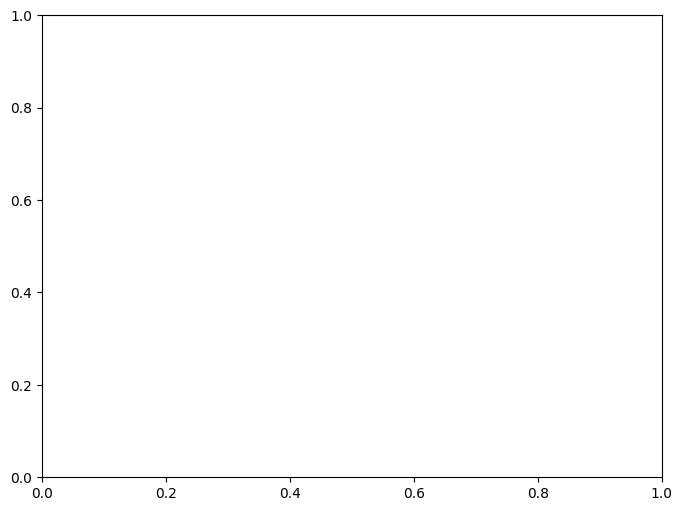

In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# import numpy as np

# # Replace -1 (unassigned) with a new number if you want to color them separately
# labels = labels_global.copy()
# unassigned_mask = labels == -1
# labels[unassigned_mask] = -1  # we can color these separately if needed

# # Map large cluster IDs to sequential 0..num_clusters-1 for color mapping
# unique_labels = np.unique(labels)
# label_map = {old: new for new, old in enumerate(unique_labels)}
# labels_mapped = np.array([label_map[l] for l in labels])

# # PCA to 2D
# pca = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X)

# plt.figure(figsize=(8,6))
# plt.scatter(
#     X_pca[:,0], X_pca[:,1], 
#     c=labels_mapped, s=10, cmap='tab20', alpha=0.6
# )
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
# plt.title("LSH-Accelerated KMeans Clusters (PCA 2D)")
# plt.colorbar(label="Cluster ID")
# plt.show()


In [28]:
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# import pandas as pd

# # Assuming X and labels_global already exist
# # X: (n_samples, n_features)
# # labels_global: (n_samples,)

# # -----------------------------
# # 1. PCA projection (fast)
# # -----------------------------
# pca = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X)

# plt.figure(figsize=(8,6))
# plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_global, s=10, cmap='tab20', alpha=0.6)
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
# plt.title("LSH-Accelerated KMeans Clusters (PCA 2D)")
# plt.colorbar(label="Cluster ID")
# plt.show()

# # -----------------------------
# # 2. t-SNE projection (slower, non-linear)
# # -----------------------------
# tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
# X_tsne = tsne.fit_transform(X)

# plt.figure(figsize=(8,6))
# plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_global, s=10, cmap='tab20', alpha=0.6)
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.title("LSH-Accelerated KMeans Clusters (t-SNE 2D)")
# plt.colorbar(label="Cluster ID")
# plt.show()

# # -----------------------------
# # 3. Cluster size histogram
# # -----------------------------
# import numpy as np

# unique_labels, counts = np.unique(labels_global, return_counts=True)
# plt.figure(figsize=(10,4))
# plt.bar(unique_labels, counts)
# plt.xlabel("Cluster ID")
# plt.ylabel("Number of items")
# plt.title("Cluster Sizes")
# plt.show()


# Outdated - Prototyping:

### **Loading subset data and generating placeholder LSH data:**

In [32]:
root_path = "../" #All the data is outside this folder. 

Note: If we just read the e.g. first 200 lines, we will only get the track_genre = acoustic entries.
Therefore, when making the subset, we need to mix the entries that we read. 

In [60]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Load subset of CSV
# -----------------------------
# Load only first 200 rows (change nrows as needed)
#df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv", nrows=200)

# Read whole CSV: 
df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv")

# Drop 'Unnamed: 0' if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Take a random sample of 200 rows - overwrite the df, which covers the entire dataset. 
df = df.sample(n=200, random_state=42)

print("Checking how many different track genres are in the subset:")
display( pd.DataFrame(df['track_genre'].value_counts()) )


# Drop 'Unnamed: 0' if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Data loaded:", df.shape)
display(df.head())

# Drop non-numeric columns if any (e.g., 'track_id','artists', etc.)
numeric_df = df.select_dtypes(include=[np.number])
print("Numeric columns used:", numeric_df.columns.tolist())


Checking how many different track genres are in the subset:


,count
track_genre,
heavy-metal,7
drum-and-bass,7
industrial,6
study,6
electronic,5
...,...
synth-pop,1
pagode,1
indian,1


Data loaded: (200, 25)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
37609,2gpz5SQb1NEPPxjbSglAZK,Pappo,Buscando un Amor,Trabajo Forzado,23,248066,NaN,0.547,0.699,9,...,0.1310,0.622,75.814,4,heavy-metal,Trabajo Forzado - Pappo,4373.0,1433.0,248000.0,blues;rock;rock argentino;argentina;blues rock...
35970,3oYj1UaQtkX0R9iuaV2jMj,Eterna Inocencia,No bien abran las flores,Hojas Amarillas,31,255905,NaN,0.576,0.709,2,...,0.1250,0.579,140.003,4,hardcore,Hojas Amarillas - Eterna Inocencia,2195.0,428.0,255000.0,melodic hardcore;hardcore melodico;hardcore pu...
61541,2WkjVlKU47qVKyPUehA5eH,SONNY NITEZ,MORNING 2007,MORNING 2007,52,118763,NaN,0.752,0.485,5,...,0.3420,0.819,95.003,4,sad,MORNING 2007 - SONNY NITEZ,69823.0,11268.0,118000.0,NaN
652,4XBcShO4h4X55x9yMmyKHL,Allman Brown,1000 Years,Sweetest Thing,54,218502,NaN,0.546,0.411,2,...,0.0955,0.528,79.785,4,acoustic,Sweetest Thing - Allman Brown,326871.0,75287.0,218000.0,singer-songwriter;folk rock;indie;rock;england...
37281,7pvMOx4cYIamyNeYLVhTWS,Tren Loco,Venas De Acero,Venas De Acero,25,362520,NaN,0.534,0.949,4,...,0.5370,0.334,114.988,4,heavy-metal,Venas De Acero - Tren Loco,3454.0,858.0,408000.0,heavy metal;speed metal;argentina;heavy argent...


Numeric columns used: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'lfm_playcount', 'lfm_listeners', 'lfm_duration_ms']


In [61]:
#Different type of track genres in the list: 
print(df["track_genre"].unique()) 

['heavy-metal' 'hardcore' 'sad' 'acoustic' 'blues' 'forro' 'iranian'
 'country' 'j-idol' 'emo' 'mandopop' 'r-n-b' 'industrial' 'bluegrass'
 'alt-rock' 'party' 'show-tunes' 'ambient' 'dub' 'latino' 'french'
 'sertanejo' 'trance' 'swedish' 'rockabilly' 'disney' 'tango'
 'chicago-house' 'sleep' 'salsa' 'trip-hop' 'k-pop' 'death-metal'
 'drum-and-bass' 'power-pop' 'cantopop' 'electronic' 'club' 'brazil'
 'happy' 'romance' 'dancehall' 'black-metal' 'spanish' 'malay' 'study'
 'j-dance' 'minimal-techno' 'kids' 'progressive-house' 'hip-hop' 'ska'
 'gospel' 'rock-n-roll' 'funk' 'anime' 'comedy' 'grindcore' 'classical'
 'german' 'singer-songwriter' 'new-age' 'guitar' 'idm' 'edm' 'pop'
 'electro' 'grunge' 'opera' 'mpb' 'breakbeat' 'afrobeat' 'latin'
 'metalcore' 'goth' 'groove' 'garage' 'piano' 'children' 'turkish'
 'deep-house' 'pop-film' 'synth-pop' 'pagode' 'indian' 'dubstep'
 'alternative']


In [66]:
# -----------------------------
# 2. Generate approximate LSH-like vectors
# -----------------------------
# Simulate LSH signatures by random projection
# (this approximates hashing similar vectors together)
def generate_lsh_vectors(data, n_bits=32, seed=42):
    rng = np.random.RandomState(seed)
    random_planes = rng.randn(data.shape[1], n_bits)
    projections = np.dot(data, random_planes)
    lsh_vectors = (projections > 0).astype(int)
    return lsh_vectors


#generate_lsh_vectors() uses random hyperplane projection (a standard way to approximate LSH).
#You can control the number of bits (hash length) with n_bits.

lsh_vectors = generate_lsh_vectors(numeric_df, n_bits=64)

lsh_vectors = lsh_vectors + np.random.normal(0, 0.01, lsh_vectors.shape) #Important: Adding noise. 
#Without this, the place-holder clusters will be too similar, and we will only get 1 cluster.

print("LSH-like vectors shape:", lsh_vectors.shape)

LSH-like vectors shape: (200, 64)


### **K-means:**

Centroid, Partition-based. <br>
Requires a user-defined K-value. <br>
Might be hard to scale up. 

In [34]:
#pip install scikit-learn


Cluster assignments:


,count
cluster,
2,45
4,44
1,43
0,38
3,30


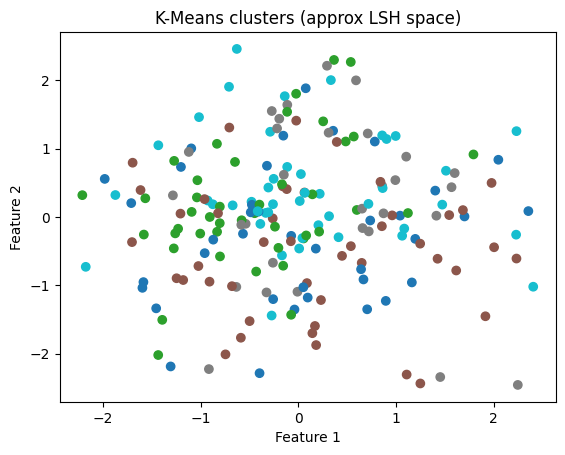

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


n_clusters = 5 #For now we put the k-value as 5. 
#But we can later e.g. try to put it near the amount of different genres, or something corresponding.


# -----------------------------
# Run K-Means clustering
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lsh_vectors)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster assignments:")
display( pd.DataFrame(df['cluster'].value_counts()) )

# -----------------------------
# Visualize
# -----------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['cluster'], cmap='tab10')
plt.title("K-Means clusters (approx LSH space)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
#We can compare how well clusters align with the track genre:
pd.crosstab(df['track_genre'], df['cluster']) 

cluster,0,1,2,3,4
track_genre,,,,,
acoustic,1,0,0,0,0
afrobeat,0,0,0,0,1
alt-rock,0,0,2,1,0
alternative,0,1,0,0,0
ambient,2,1,1,0,0
...,...,...,...,...,...
synth-pop,0,0,0,0,1
tango,0,0,0,0,1
trance,1,0,1,0,1


### **CURE (Clustering Using REpresentatives) algorithm:**

Hierarchical clustering. Uses representative points instead of centroids. <br>
Might be more suitable for large datasets. 

In [ ]:
# #Pseudo CURE algorithm: 

# import numpy as np
# from sklearn.cluster import AgglomerativeClustering

# def simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10):
#     # Step 1: Hierarchical clustering
#     agg = AgglomerativeClustering(n_clusters=n_clusters)
#     labels = agg.fit_predict(X)
    
#     # Step 2: Compute representative points per cluster
#     reps = []
#     for k in range(n_clusters):
#         points = X[labels == k]
#         centroid = points.mean(axis=0)
#         dists = np.linalg.norm(points - centroid, axis=1)
#         farthest_idx = np.argsort(dists)[-rep_points:]
#         selected = points[farthest_idx]
#         reps.append(centroid + shrink_factor * (selected - centroid))
#     return labels, reps


/home/henrikk17/miniconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['explicit']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


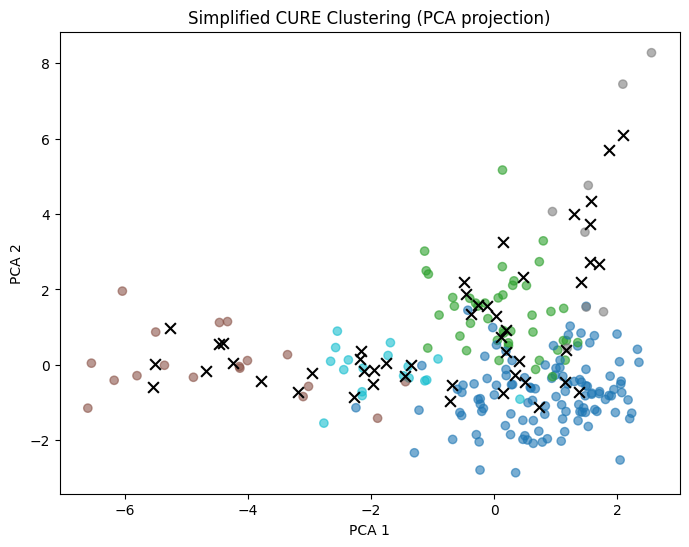

cluster
0    113
1     43
4     18
2     18
3      8
Name: count, dtype: int64


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.impute import SimpleImputer

# -----------------------------
# 1. Prepare data
# -----------------------------

#numeric_df = numeric_df.dropna() #Drop the NA values. We can also use imputer transformer, to approximate some value to fill in, as covered in the course. 

numeric_df = df.select_dtypes(include=[np.number])

# Impute missing values (NaN) with column mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(numeric_df)

# Scale
X = StandardScaler().fit_transform(X_imputed)


# -----------------------------
# 2. Simplified CURE algorithm
# -----------------------------
def simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10):
    # Step 1: Agglomerative clustering (approximation of CURE’s merging)
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agg.fit_predict(X)
    
    # Step 2: Compute representative points for each cluster
    reps = []
    for k in range(n_clusters):
        points = X[labels == k]
        if len(points) == 0:
            continue
        centroid = points.mean(axis=0)
        dists = np.linalg.norm(points - centroid, axis=1)
        farthest_idx = np.argsort(dists)[-rep_points:]
        selected = points[farthest_idx]
        # shrink points toward the centroid
        rep_points_k = centroid + shrink_factor * (selected - centroid)
        reps.append(rep_points_k)
    return labels, reps

labels, reps = simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10)
df["cluster"] = labels

# -----------------------------
# 3. Visualize in 2D (via PCA)
# -----------------------------
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", alpha=0.6)
plt.title("Simplified CURE Clustering (PCA projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Plot representative points (also projected to 2D)
for rep_set in reps:
    rep_2d = pca.transform(rep_set)
    plt.scatter(rep_2d[:, 0], rep_2d[:, 1], c="black", marker="x", s=60)

plt.show()

print(df["cluster"].value_counts())


In [ ]:
#pip install pyclustering

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pyclustering.cluster.cure import cure
from pyclustering.utils import timedcall
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load and prepare data
# -----------------------------
df = pd.read_csv("genre_avg_signatures.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.sample(n=200, random_state=42)

numeric_df = df.select_dtypes(include=[np.number])
X = StandardScaler().fit_transform(numeric_df)

# -----------------------------
# 2. Run CURE clustering
# -----------------------------
# n_clusters: desired number of clusters
# number_rep_points: number of representative points per cluster
# compression: shrink factor (0–1)
n_clusters = 5
number_rep_points = 10
compression = 0.5

cure_instance = cure(data=X.tolist(),
                     number_cluster=n_clusters,
                     number_represent_points=number_rep_points,
                     compression=compression)

(ticks, _) = timedcall(cure_instance.process)
clusters = cure_instance.get_clusters()

# -----------------------------
# 3. Assign cluster labels
# -----------------------------
labels = np.empty(X.shape[0])
for cluster_id, indices in enumerate(clusters):
    labels[indices] = cluster_id

df['cluster'] = labels.astype(int)

print("Cluster counts:\n", df['cluster'].value_counts())

# -----------------------------
# 4. Visualize 2D projection
# -----------------------------
plt.scatter(X[:, 0], X[:, 1], c=df['cluster'], cmap='tab10')
plt.title("CURE clustering (approx view)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**

Density-based. Densly packed. <br>
Note: Usually works well on PCA or UMAP dimensionality-reduced data, but can struggle with high dimensionality. 

### **Graph-Based Clustering:**

- Nodes = songs
- Edges = similarity between songs (weighted)

Community detection to identify “music communities”

**Louvain algorithm**

Two-phase. Each note starts as a community. No user-defined K-value. Works decent on large data/ is scalable. 

**Spectral clustering**

Uses eigenvectors and K-means. Can be used on k-nearest neighbors graph (k-NN graph) from LSH. 

**Girvan-Newman Algorithm**

Can find communities. Might be tricky on large graphs, although limiting edges based on the LSH buckets, might help. 